## WorldView Stereopair Selection: SpaceNet UCSD Example

This notebook documents the stereo-pair selection analysis used to choose candidate pairs from the [IARPA CORE3D / SpaceNet UCSD dataset](https://spacenet.ai/core3d/) for the companion processing notebooks:

- [`worldview_spacenet_ucsd_stereo_14deg_6d.ipynb`](./worldview_spacenet_ucsd_stereo_14deg_6d.ipynb)
- [`worldview_spacenet_ucsd_stereo_18deg_13d.ipynb`](./worldview_spacenet_ucsd_stereo_18deg_13d.ipynb)
- [`worldview_spacenet_ucsd_stereo_21deg_12d.ipynb`](./worldview_spacenet_ucsd_stereo_21deg_12d.ipynb)

These replace the earlier single-pair example in [`worldview_spacenet_ucsd_stereo.ipynb`](./worldview_spacenet_ucsd_stereo.ipynb), which used a pair with a ~36° convergence angle that reviewer feedback flagged as too large for a mixed urban + natural scene.

---

## Why pick a new pair?

**Reviewer feedback on the original notebook:**

> *Some of these convergence angles are really large — 38° for Atlanta and 33° for UCSD. That's not ideal for urban, that's more ideal for flat open areas. Urban should look much better in the ~15–20° range.*

The original UCSD pair (`1040010007A3D100` × `1040010007A93700`, 2015-02-11/12) has a convergence angle of **~36°**, which is in the "flat open area" regime rather than the urban sweet spot. The goal of this notebook is to rigorously re-scan all 35 WV3 scenes available for UCSD, compute pair geometry with `asp_plot.stereopair_metadata_parser`, and select three new pairs with more appropriate geometry for the mixed campus-and-coastal-hills terrain at UCSD.

### Background: stable imaging geometry

Jeong, J. & Kim, T. (2016), *Comparison of positioning accuracy of a rigorous sensor model and two rational function models for weak stereo geometry*, ISPRS Journal of Photogrammetry and Remote Sensing 82(8): 625–633 — <https://www.sciencedirect.com/science/article/abs/pii/S0099111216301021>:

> Stable imaging geometry, in addition to a precise sensor model, is also necessary to achieve detailed mapping. The stability of the imaging geometry can be expressed by the values of three angles: the convergence, bisector elevation (BIE), and asymmetry angles. The convergence angle reflects the base-to-height ratio; the BIE angle describes the obliqueness of the epipolar plane; the asymmetry angle specifies the level of symmetry between the left and right observation rays. In the ideal imaging geometry, the epipolar plane would be orthogonal (90° BIE angle) and symmetric (0° asymmetry angle) to the ground plane, to avoid accuracy degradation.

So the ideal is **BIE → 90°** and **asymmetry → 0°**. In this notebook these two angles are treated as **secondary tiebreakers**: they only move a pair up or down the ranking when they are notably far from ideal (BIE ≲ 70°, asymm ≳ 12°).

### Convergence target for this scene

Purely urban stereo analyses cite **~5–15°** as the ideal convergence range — see Aguilar, M.Á. et al. (2019), *3D modelling of urban structures from very high resolution satellite imagery: a comparative analysis of convergence angle effect*, European Journal of Remote Sensing, 52(sup1): 1–13 — <https://www.tandfonline.com/doi/full/10.1080/22797254.2018.1551069#abstract>. Small convergence reduces occlusion and matching failures on tall, steep-sided building facades.

But UCSD (and Atlanta) are **mixed** landscapes — campus/residential blocks plus deep coastal valleys, cliffs, and hills toward Mount Soledad / Torrey Pines. Pure low-convergence pairs under-constrain height recovery over the natural, lower-slope portions. Rules of thumb used in this notebook:

- **Urban-only scenes**: ~5–15° is ideal (minimizes building occlusion).
- **Natural / low-slope terrain**: higher convergence (≳ 25°) is beneficial — the larger base-to-height ratio improves vertical precision where occlusion is not the limiting factor.
- **Mixed urban + natural scenes (UCSD, Atlanta)**: **~15–25°** is a practical middle ground.

### Scoring priority

| Priority | Criterion | Direction |
|---|---|---|
| Primary | Convergence angle | Target 15–25° |
| Primary | ROI overlap (% + containment of existing 3 × 3 km ROI) | Larger, full containment required |
| Primary | Temporal separation \|Δt\| (days) | Smaller |
| Primary | Solar geometry similarity (\|Δsun_el\|, \|Δsun_az\|, UTC hour delta) | Smaller |
| Primary | Off-nadir angle per scene | Smaller (finer GSD, less oblique) |
| Primary | Sensor consistency | Prefer WV3 + WV3 |
| Secondary | BIE angle | Tiebreaker; penalize only if ≲ 70° |
| Secondary | Asymmetry angle | Tiebreaker; penalize only if ≳ 12° |


---

## Setup

This notebook only downloads the small `*.tar` **metadata** archives (~2 MB each) — not the ~800 MB `*.NTF` images — because all we need to assess pair geometry is the XML camera metadata. Files go to `/tmp/ucsd_scene_selection/` and are cleaned up at the end.

In [1]:
import os
import shutil
import subprocess
import tempfile
from itertools import combinations
from pathlib import Path

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import box

from asp_plot.stereopair_metadata_parser import StereopairMetadataParser
from asp_plot.utils import get_xml_tag

WORK_DIR = Path("/tmp/ucsd_scene_selection")
TAR_DIR = WORK_DIR / "tars"
XML_DIR = WORK_DIR / "xmls"
FLAT_DIR = WORK_DIR / "flat_xmls"
for d in (WORK_DIR, TAR_DIR, XML_DIR, FLAT_DIR):
    d.mkdir(parents=True, exist_ok=True)

S3_PREFIX = "s3://spacenet-dataset/Hosted-Datasets/CORE3D-Public-Data/Satellite-Images/UCSD/WV3/PAN/"

# Region of interest used in the original UCSD notebook — UTM Zone 11N
# (EPSG:32611): xmin ymin xmax ymax. All new pairs must fully cover this ROI.
T_PROJWIN = (476000, 3635600, 479000, 3638600)
UTM_EPSG = 32611

# Original notebook's pair — must be excluded from the ranked selection
EXISTING_PAIR = frozenset({"1040010007A3D100", "1040010007A93700"})


---

## 1. Discover all WV3 scenes on S3

The SpaceNet CORE3D UCSD bucket contains 35 WV3 panchromatic scenes in `WV3/PAN/`. We list them with `aws s3 ls --no-sign-request` and capture the `.tar` filenames.

In [2]:
result = subprocess.run(
    ["aws", "s3", "ls", "--no-sign-request", S3_PREFIX],
    capture_output=True, text=True, check=True,
)
tar_names = sorted(
    line.split()[-1]
    for line in result.stdout.strip().splitlines()
    if line.endswith(".tar")
)
print(f"Found {len(tar_names)} tar archives on S3.")
print("First 3:")
for t in tar_names[:3]:
    print(" ", t)


Found 35 tar archives on S3.
First 3:
  01JAN16WV031300016JAN01185802-P1BS-500647760070_01_P001_________AAE_0AAAAABPABN0.tar
  05JAN15WV031300015JAN05183041-P1BS-500647758090_01_P001_________AAE_0AAAAABPABS0.tar
  06FEB15WV031300015FEB06184344-P1BS-500647761030_01_P001_________AAE_0AAAAABPABQ0.tar


## 2. Download metadata archives and extract XMLs

Each `.tar` archive is ~2 MB. The `.NTF` imagery (~800 MB each) is **not** downloaded — pair assessment uses only the XML camera models.

In [3]:
for name in tar_names:
    dst = TAR_DIR / name
    if dst.exists() and dst.stat().st_size > 0:
        continue
    subprocess.run(
        ["aws", "s3", "--no-sign-request", "cp",
         f"{S3_PREFIX}{name}", str(dst), "--only-show-errors"],
        check=True,
    )
print(f"Tars on disk: {len(list(TAR_DIR.glob('*.tar')))}")

# Extract each tar (idempotent — tar -x overwrites unchanged files)
for tar in TAR_DIR.glob("*.tar"):
    subprocess.run(["tar", "xf", str(tar), "-C", str(XML_DIR)], check=True)

# The archives nest deeply; pull the *P1BS*.XML files out into a flat dir
for xml in XML_DIR.rglob("*P1BS*.XML"):
    if "PAN" in str(xml):
        shutil.copy(xml, FLAT_DIR / xml.name)
print(f"P1BS XMLs flattened: {len(list(FLAT_DIR.glob('*.XML')))}")


Tars on disk: 35


P1BS XMLs flattened: 35


## 3. Extract per-scene metadata

We use `StereopairMetadataParser.get_id_dict(catid, xml)` to parse each XML into a dict with sensor, date, viewing geometry, solar geometry, GSD, footprint polygon, and ephemeris. The parser is instantiated with a throwaway 2-XML directory (just to satisfy `__init__`); we call `get_id_dict` manually for each of the 35 scenes — this is N-scene-safe and avoids the built-in `dg_mosaic` path the class takes when it sees > 2 XMLs in a single directory (intended for mosaicking tiles of one scene).

In [4]:
# Set up a dummy parser — get_id_dict() and pair_dict() only need `self` for
# helper methods (xml2poly, getEphem_gdf, etc.) and do not use self.image_list.
_dummy = tempfile.mkdtemp()
xmls_sorted = sorted(FLAT_DIR.glob("*.XML"))
for x in xmls_sorted[:2]:
    shutil.copy(x, _dummy)
parser = StereopairMetadataParser(_dummy)

scene_dicts = []
rows = []
for x in xmls_sorted:
    catid = get_xml_tag(str(x), "CATID")
    d = parser.get_id_dict(catid, str(x), geteph=True)
    scene_dicts.append(d)
    rows.append({
        "catid": d["catid"],
        "sensor": d["sensor"],
        "date": d["date"],
        "off_nadir": d["meanoffnadirviewangle"],
        "sat_az": d["meansataz"],
        "sat_el": d["meansatel"],
        "sun_az": d["meansunaz"],
        "sun_el": d["meansunel"],
        "gsd_m": d["meanproductgsd"],
        "cloud": d["cloudcover"],
    })

scene_df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
print(f"{len(scene_df)} scenes parsed.")
scene_df


35 scenes parsed.


,catid,sensor,date,off_nadir,sat_az,sat_el,sun_az,sun_el,gsd_m,cloud
0,104001000365CA00,WV03,2014-10-27 18:25:10.483175,17.0,161.3,71.2,157.8,41.6,0.33,0.00
1,10400100039E7C00,WV03,2014-10-28 18:40:08.733775,23.2,263.8,64.4,162.6,42.3,0.36,0.00
2,104001000496A100,WV03,2014-11-09 18:29:48.722375,1.1,184.8,88.6,160.8,38.1,0.31,0.01
3,1040010004B41D00,WV03,2014-11-22 18:34:28.860375,13.0,227.6,75.6,162.6,35.1,0.32,0.00
4,10400100047BBB00,WV03,2014-11-28 18:29:01.304775,14.7,172.6,73.7,161.0,33.5,0.33,0.00
5,10400100057DD500,WV03,2014-12-23 18:22:36.081975,24.1,132.4,63.3,157.2,30.3,0.36,0.00
6,1040010005843100,WV03,2015-01-05 18:30:41.419775,8.2,146.0,80.8,157.4,31.2,0.31,0.00
7,10400100071D8800,WV03,2015-01-24 18:35:47.652175,16.3,199.2,71.8,155.5,34.3,0.33,0.00
8,1040010007713300,WV03,2015-02-06 18:43:44.791775,22.6,239.3,65.0,155.5,38.2,0.36,0.00
9,1040010007A3D100,WV03,2015-02-11 18:23:49.684775,24.3,81.0,63.2,149.0,37.7,0.36,0.00


## 4. Enumerate all unique pairs and compute geometry metrics

With 35 scenes we have $\binom{35}{2} = 595$ candidate pairs. For each pair we compute (via `parser.pair_dict`):

- `conv_ang` — convergence angle (degrees)
- `bh_ratio` — base-to-height ratio (derived from convergence)
- `bie_ang` — bisector elevation angle (degrees; ideal 90°)
- `asymm_ang` — asymmetry angle (degrees; ideal 0°)
- `inter_km2` — intersection-footprint area
- `inter_perc_min` — minimum of (% of each scene that is intersected)

Plus manually-computed acquisition-condition deltas:

- `dt_days` — temporal separation (calendar days)
- `delta_sun_el`, `delta_sun_az` — solar geometry differences (degrees; az uses circular distance)
- `tod_hour_delta` — time-of-day (UTC hour) delta — sun-shadow-direction proxy
- `roi_contained` — does the intersection polygon fully contain the existing 3 × 3 km ROI?

In [5]:
roi_utm_poly = box(*T_PROJWIN)
roi_latlon_poly = (
    gpd.GeoDataFrame(geometry=[roi_utm_poly], crs=f"EPSG:{UTM_EPSG}")
    .to_crs("EPSG:4326")
    .geometry.iloc[0]
)

pair_rows = []
for d1, d2 in combinations(scene_dicts, 2):
    if d1["date"] > d2["date"]:
        d1, d2 = d2, d1
    pairname = f"{d1['catid']}_{d2['catid']}"
    p = parser.pair_dict(d1, d2, pairname)

    dt_days = p["dt"].total_seconds() / 86400.0
    delta_sun_el = abs(d1["meansunel"] - d2["meansunel"])
    dsun_az = abs(d1["meansunaz"] - d2["meansunaz"])
    delta_sun_az = min(dsun_az, 360 - dsun_az)
    hour1 = d1["date"].hour + d1["date"].minute / 60.0
    hour2 = d2["date"].hour + d2["date"].minute / 60.0
    dh = abs(hour1 - hour2)
    tod_hour_delta = min(dh, 24 - dh)

    if p["intersection"] is not None:
        roi_contained = p["intersection"].contains(roi_latlon_poly)
        inter_area = p["intersection_area"]
        inter_perc = min(p["intersection_area_perc"])
    else:
        roi_contained = False
        inter_area = None
        inter_perc = None

    pair_rows.append({
        "pairname": pairname,
        "catid1": d1["catid"], "catid2": d2["catid"],
        "sensor1": d1["sensor"], "sensor2": d2["sensor"],
        "date1": d1["date"], "date2": d2["date"],
        "dt_days": round(dt_days, 2),
        "conv_ang": p["conv_ang"],
        "bh_ratio": p["bh"],
        "bie_ang": p["bie"],
        "asymm_ang": p.get("asymmetry_angle"),
        "inter_km2": inter_area,
        "inter_perc_min": inter_perc,
        "roi_contained": roi_contained,
        "off_nadir1": d1["meanoffnadirviewangle"],
        "off_nadir2": d2["meanoffnadirviewangle"],
        "delta_sun_el": round(delta_sun_el, 2),
        "delta_sun_az": round(delta_sun_az, 2),
        "tod_hour_delta": round(tod_hour_delta, 2),
    })

pair_df = pd.DataFrame(pair_rows)
print(f"Computed {len(pair_df)} pairs.")
print(f"Pairs fully containing the ROI: {pair_df.roi_contained.sum()}")
print(f"Pairs with convergence in 15–25°: {((pair_df.conv_ang >= 15) & (pair_df.conv_ang <= 25)).sum()}")


Computed 595 pairs.
Pairs fully containing the ROI: 595
Pairs with convergence in 15–25°: 163


### Sanity-check: the existing notebook's pair

For context, here is the geometry of the original UCSD notebook's pair — a convergence angle of ~36° confirms the reviewer's observation that it sits in the "flat open area" regime rather than the urban/mixed sweet spot.

In [6]:
existing = pair_df[
    pair_df.apply(lambda r: frozenset({r.catid1, r.catid2}) == EXISTING_PAIR, axis=1)
]
existing[[
    "pairname", "dt_days", "conv_ang", "bh_ratio", "bie_ang", "asymm_ang",
    "inter_perc_min", "delta_sun_el", "delta_sun_az",
    "off_nadir1", "off_nadir2",
]]


,pairname,dt_days,conv_ang,bh_ratio,bie_ang,asymm_ang,inter_perc_min,delta_sun_el,delta_sun_az,off_nadir1,off_nadir2
442,1040010007A3D100_1040010007A93700,1.01,35.94,0.65,81.14,8.84,78.53,1.9,4.3,24.3,8.4


## 5. Filter and score

### Filters

1. The intersection polygon must fully contain the 3 × 3 km ROI (`roi_contained == True`).
2. Convergence must not be missing.
3. The existing notebook's pair is removed.

### Scoring

Smaller score → better. Weights reflect the priority table from the intro: convergence dominates, followed by solar geometry and temporal separation. BIE and asymmetry are applied as penalty *flags* that activate only when notably bad (BIE < 70° or asymm > 12°), so they don't dominate a well-behaved pair's ranking.

```text
score = 3.0 · conv_penalty            # 0 inside [15, 25°], else distance from that band
      + 0.15 · dt_days
      + 0.30 · |Δsun_el|
      + 0.10 · |Δsun_az|
      + 0.10 · mean(off_nadir1, off_nadir2)
      + 5.0  · (bie_ang < 70)
      + 5.0  · (asymm_ang > 12)
```

In [7]:
def conv_penalty(c):
    if 15 <= c <= 25:
        return 0.0
    return float(min(abs(c - 15), abs(c - 25)))

scored = pair_df[pair_df.roi_contained & pair_df.conv_ang.notna()].copy()
scored = scored[
    scored.apply(lambda r: frozenset({r.catid1, r.catid2}) != EXISTING_PAIR, axis=1)
].copy()

scored["conv_penalty"] = scored["conv_ang"].apply(conv_penalty)
scored["bie_flag"] = (scored["bie_ang"] < 70).astype(int)
scored["asymm_flag"] = (scored["asymm_ang"] > 12).astype(int)

scored["score"] = (
    3.0  * scored["conv_penalty"]
  + 0.15 * scored["dt_days"]
  + 0.30 * scored["delta_sun_el"]
  + 0.10 * scored["delta_sun_az"]
  + 0.10 * scored[["off_nadir1", "off_nadir2"]].mean(axis=1)
  + 5.0  * scored["bie_flag"]
  + 5.0  * scored["asymm_flag"]
)

scored = scored.sort_values("score").reset_index(drop=True)
print(f"Candidates after filtering: {len(scored)}")

display_cols = [
    "pairname", "dt_days", "conv_ang", "bie_ang", "asymm_ang",
    "inter_perc_min", "delta_sun_el", "delta_sun_az",
    "tod_hour_delta", "off_nadir1", "off_nadir2", "score",
]
scored[display_cols].head(15)


Candidates after filtering: 594


,pairname,dt_days,conv_ang,bie_ang,asymm_ang,inter_perc_min,delta_sun_el,delta_sun_az,tod_hour_delta,off_nadir1,off_nadir2,score
0,1040010018921400_10400100190C5100,6.00,19.60,72.98,10.40,91.80,1.5,2.6,0.08,21.8,12.1,3.3050
1,104001000365CA00_104001000496A100,13.00,17.52,79.95,9.84,90.13,3.5,3.0,0.07,17.0,1.1,4.2050
2,1040010007A93700_1040010007CA4D00,11.99,21.21,84.31,2.73,94.82,3.1,4.4,0.13,8.4,12.9,4.2335
3,104001000496A100_10400100047BBB00,19.00,14.93,81.16,8.64,94.32,4.6,0.2,0.00,1.1,14.7,5.2500
4,1040010007A3D100_1040010007CA4D00,13.01,22.84,71.73,11.63,81.98,5.0,0.1,0.13,24.3,12.9,5.3215
5,1040010004B41D00_10400100047BBB00,6.00,14.14,76.31,2.08,97.25,1.6,1.6,0.08,13.0,14.7,5.5050
6,10400100071D8800_1040010007A93700,19.00,17.14,78.38,7.00,93.51,5.3,2.2,0.07,16.3,8.4,5.8950
7,1040010005843100_10400100071D8800,19.00,14.61,77.55,8.35,93.48,3.1,1.9,0.08,8.2,16.3,6.3650
8,1040010016C57700_10400100179C8D00,26.01,22.19,70.38,4.07,94.79,4.2,1.5,0.17,18.4,21.9,7.3265
9,104001000365CA00_1040010004B41D00,26.01,18.36,75.94,4.01,96.78,6.5,4.8,0.15,17.0,13.0,7.8315


## 6. Visualize the ranked candidates

Two views:

1. **Scatter** — convergence angle vs. temporal separation, colored by asymmetry, sized by inverse score. The 15–25° target band is shaded.
2. **Map** — scene footprints for the top 3 pairs over an Esri WorldImagery basemap with the ROI highlighted.

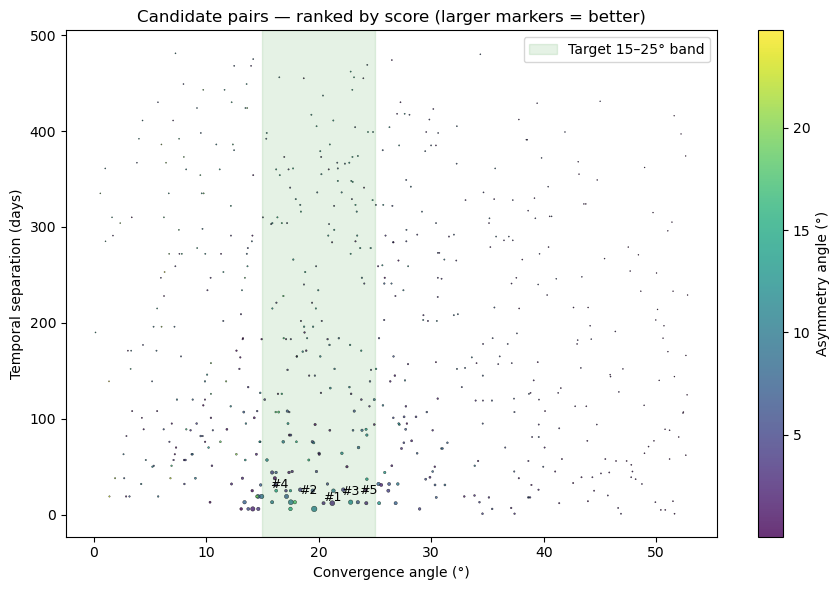

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    scored["conv_ang"], scored["dt_days"],
    c=scored["asymm_ang"], cmap="viridis",
    s=60 * np.clip(1 / (scored["score"] + 0.5), 0, 5),
    alpha=0.8, edgecolor="k", linewidth=0.3,
)
cb = plt.colorbar(sc, ax=ax, label="Asymmetry angle (°)")
ax.axvspan(15, 25, color="green", alpha=0.10, label="Target 15–25° band")
for i in range(min(5, len(scored))):
    row = scored.iloc[i]
    ax.annotate(f"#{i+1}", (row["conv_ang"], row["dt_days"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set_xlabel("Convergence angle (°)")
ax.set_ylabel("Temporal separation (days)")
ax.set_title("Candidate pairs — ranked by score (larger markers = better)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


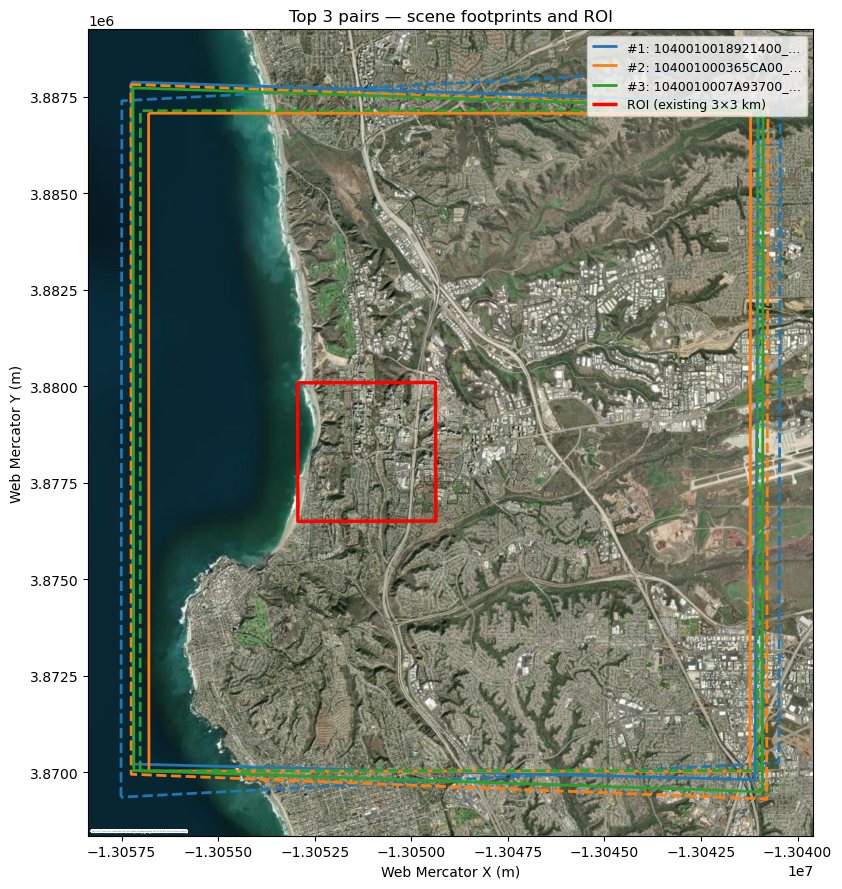

In [9]:
fig, ax = plt.subplots(figsize=(9, 9))

top3_idx = scored.index[:3]
colors = ["tab:blue", "tab:orange", "tab:green"]

for i, (idx, color) in enumerate(zip(top3_idx, colors)):
    row = scored.loc[idx]
    g1 = next(d["geom"] for d in scene_dicts if d["catid"] == row["catid1"])
    g2 = next(d["geom"] for d in scene_dicts if d["catid"] == row["catid2"])
    for g, style in [(g1, "--"), (g2, "-")]:
        gdf = gpd.GeoDataFrame(geometry=[g], crs="EPSG:4326").to_crs(3857)
        gdf.boundary.plot(ax=ax, color=color, linestyle=style, linewidth=2,
                          label=f"#{i+1}: {row['pairname'][:17]}…" if style == "-" else None)

roi_gdf = gpd.GeoDataFrame(geometry=[roi_utm_poly], crs=f"EPSG:{UTM_EPSG}").to_crs(3857)
roi_gdf.boundary.plot(ax=ax, color="red", linewidth=2.5, label="ROI (existing 3×3 km)")

ctx.add_basemap(ax, crs=3857, source=ctx.providers.Esri.WorldImagery, attribution_size=0)
ax.set_title("Top 3 pairs — scene footprints and ROI")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlabel("Web Mercator X (m)")
ax.set_ylabel("Web Mercator Y (m)")
plt.tight_layout()
plt.show()


## 7. Selected pairs

The three pairs carried forward into the processing notebooks were chosen from the ranked candidates to **span the 15–25° convergence band** while keeping temporal separation, solar geometry, and BIE/asymmetry all in good shape. They are all same-sensor (WV3 + WV3) and all fully contain the 3 × 3 km ROI from the original notebook.

| Pair folder / notebook suffix | catid1 × catid2 | Conv (°) | \|Δt\| (d) | BIE (°) | Asymm (°) | Overlap % | \|Δsun_el\| (°) |
|---|---|---|---|---|---|---|---|
| `14deg_6d`  | `1040010004B41D00` × `10400100047BBB00` | 14.14 | 6  | 76.3 | 2.1  | 97.3 | 1.6 |
| `18deg_13d` | `104001000365CA00` × `104001000496A100` | 17.52 | 13 | 80.0 | 9.8  | 90.1 | 3.5 |
| `21deg_12d` | `1040010007A93700` × `1040010007CA4D00` | 21.21 | 12 | 84.3 | 2.7  | 94.8 | 3.1 |

Compared to the original notebook's pair (conv ≈ 36°, asymm ≈ 9°, overlap ≈ 79%) these three have:

- **Lower convergence** (all inside the mixed-terrain target band).
- **Higher overlap** of the ROI, so the processed scene footprint is comparable.
- **Smaller sun-elevation deltas** in the 14° and 21° pairs, which reduces shadow-driven matching mismatches.

The 18° pair has a noticeably asymmetric geometry (asymm 9.8°, just under the 12° flag threshold) — it's retained because its convergence sits at the middle of the urban-ideal band and gives us a useful mid-convergence comparison, but we'll note when reviewing its DEM whether the asymmetry shows up in the residuals.

**Processing notebooks** (same cropped ROI, same reference DEM, same pipeline):

- `worldview_spacenet_ucsd_stereo_14deg_6d.ipynb`
- `worldview_spacenet_ucsd_stereo_18deg_13d.ipynb`
- `worldview_spacenet_ucsd_stereo_21deg_12d.ipynb`

In [10]:
selected_pairs = [
    ("14deg_6d",  "1040010004B41D00", "10400100047BBB00"),
    ("18deg_13d", "104001000365CA00", "104001000496A100"),
    ("21deg_12d", "1040010007A93700", "1040010007CA4D00"),
]
for tag, c1, c2 in selected_pairs:
    row = scored[
        scored.apply(lambda r: frozenset({r.catid1, r.catid2}) == frozenset({c1, c2}), axis=1)
    ].iloc[0]
    print(f"{tag:10s}  rank={scored.index.get_loc(row.name)+1:3d}  "
          f"conv={row.conv_ang:5.2f}°  bie={row.bie_ang:5.2f}°  asymm={row.asymm_ang:5.2f}°  "
          f"dt={row.dt_days:5.1f}d  overlap={row.inter_perc_min:5.1f}%  "
          f"Δsun_el={row.delta_sun_el:4.1f}°")


14deg_6d    rank=  6  conv=14.14°  bie=76.31°  asymm= 2.08°  dt=  6.0d  overlap= 97.2%  Δsun_el= 1.6°
18deg_13d   rank=  2  conv=17.52°  bie=79.95°  asymm= 9.84°  dt= 13.0d  overlap= 90.1%  Δsun_el= 3.5°
21deg_12d   rank=  3  conv=21.21°  bie=84.31°  asymm= 2.73°  dt= 12.0d  overlap= 94.8%  Δsun_el= 3.1°


## 8. Clean up

Remove all temporary tar/XML files. Only the XML metadata lives under `/tmp/`, so nothing outside the working directory is affected. Re-running this notebook will re-download the ~70 MB of tars from S3.

In [11]:
shutil.rmtree(WORK_DIR, ignore_errors=True)
print(f"Removed {WORK_DIR}: {not WORK_DIR.exists()}")


Removed /tmp/ucsd_scene_selection: True
